# Modelagem — Detecção de Fraude em Transações Financeiras

**Versão refatorada e mais limpa**

Este notebook implementa a modelagem do projeto com uma estrutura mais direta:

1. primeiro mostra um **resumo executivo** dos resultados, quando já existir uma execução anterior;
2. depois carrega os dados processados;
3. treina baselines e modelos;
4. gera a **tabela principal dos modelos**;
5. escolhe o modelo operacional pelo cenário `sem_pos_transacao`;
6. avalia robustez por `imbalance ratio`;
7. salva os artefatos para o relatório e dashboard.

A ideia é evitar que os resultados importantes fiquem escondidos no meio de muitas células técnicas.

## 0. Como usar este notebook

Rode na ordem normal.

- Se você já executou uma versão anterior e existe `data/modelagem/resultados_teste.csv`, a próxima seção mostra a tabela principal imediatamente.
- Se ainda não existem resultados salvos, rode o notebook inteiro. A tabela principal aparecerá novamente na seção **7. Tabela principal dos modelos**.
- O modelo final será escolhido no cenário `sem_pos_transacao`, porque ele evita depender diretamente de variáveis pós-transação que podem causar avaliação otimista.

## 1. Importações e configurações

Esta seção concentra tudo que normalmente pode precisar ser alterado: caminhos, modo rápido, custos de erro e limites de tempo.

In [40]:
from pathlib import Path
from datetime import datetime
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
)

try:
    from xgboost import XGBClassifier
    XGBOOST_DISPONIVEL = True
except Exception:
    XGBOOST_DISPONIVEL = False

try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_DISPONIVEL = True
except Exception:
    IMBLEARN_DISPONIVEL = False

try:
    import joblib
    JOBLIB_DISPONIVEL = True
except Exception:
    JOBLIB_DISPONIVEL = False

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
COLUNA_ALVO = "isFraud"

DATA_DIR = Path("data/processado")
OUTPUT_DIR = Path("data/modelagem")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Use True para testar mais rápido. Para resultado final, rode uma versão com False se o ambiente aguentar.
MODO_RAPIDO = True

# Quantidade máxima de transações legítimas usadas no treino quando MODO_RAPIDO=True.
# Todas as fraudes são preservadas.
MAX_LEGITIMAS_TREINO = 200_000
MAX_LEGITIMAS_SMOTE = 50_000

# SMOTE pode ser pesado. Deixe True para testar como planejado na proposta.
EXECUTAR_SMOTE = True

# Custos simulados para matriz de custo.
# FN costuma ser mais caro porque representa fraude não detectada.
CUSTO_FP = 10
CUSTO_FN = 500

# Metas da proposta
META_RECALL = 0.80
META_PRECISION = 0.60
META_TEMPO_MEDIO_MS = 50.0

# Cenário usado para seleção final operacional.
# O cenário completo fica como análise diagnóstica, não como decisão principal.
CENARIO_FINAL_OPERACIONAL = "sem_pos_transacao"

# GPU para XGBoost. Ative apenas se estiver usando Colab com GPU.
USAR_GPU_XGBOOST = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print(f"XGBoost disponível: {XGBOOST_DISPONIVEL}")
print(f"imbalanced-learn disponível: {IMBLEARN_DISPONIVEL}")
print(f"Modo rápido: {MODO_RAPIDO}")
print(f"Cenário final operacional: {CENARIO_FINAL_OPERACIONAL}")

XGBoost disponível: True
imbalanced-learn disponível: True
Modo rápido: True
Cenário final operacional: sem_pos_transacao


## 2. Resumo executivo rápido

Esta seção tenta carregar resultados já salvos de uma execução anterior.

Ela existe para resolver o problema de navegação: você consegue ver rapidamente a tabela principal sem procurar no meio do notebook.

In [41]:
def nome_curto_modelo(nome: str) -> str:
    nome = nome.replace(" - threshold otimizado F1", "")
    nome = nome.replace(" - threshold 0.5", "")
    nome = nome.replace("Regressão Logística - class_weight", "Regressão Logística")
    nome = nome.replace("Random Forest - class_weight", "Random Forest class_weight")
    nome = nome.replace("XGBoost - scale_pos_weight", "XGBoost scale_pos_weight")
    nome = nome.replace("Baseline regra type + amount", "Baseline regra type + amount")
    nome = nome.replace("Baseline tudo legítimo", "Baseline tudo legítimo")
    return nome


def montar_tabela_principal(resultados_teste_df: pd.DataFrame, cenario: str = "sem_pos_transacao") -> pd.DataFrame:
    df = resultados_teste_df.copy()

    if "cenario_features" in df.columns:
        df = df[df["cenario_features"] == cenario].copy()

    # Mantém os modelos mais importantes para leitura e comparação.
    mascara = (
        df["modelo"].str.contains("threshold otimizado F1", regex=False)
        | (df["modelo"] == "Baseline regra type + amount")
        | (df["modelo"] == "Baseline tudo legítimo")
    )
    df = df[mascara].copy()

    # Se houver duplicatas do mesmo modelo, mantém a melhor por F1.
    df["modelo_curto"] = df["modelo"].apply(nome_curto_modelo)
    df = df.sort_values(
        by=["f1_fraude", "recall_fraude", "precision_fraude"],
        ascending=[False, False, False],
    )
    df = df.drop_duplicates(subset=["modelo_curto"], keep="first")

    observacoes = {
        "XGBoost + SMOTE": "Melhor candidato se equilibrar F1, recall, custo e tempo",
        "XGBoost scale_pos_weight": "Costuma ser mais preciso, mas pode perder mais fraudes",
        "Random Forest class_weight": "Modelo não linear robusto, mas pode ser mais pesado",
        "Regressão Logística": "Baseline supervisionado simples e rápido",
        "Baseline regra type + amount": "Regra simples interpretável; deve ficar abaixo dos modelos",
        "Baseline tudo legítimo": "Mostra por que acurácia não serve neste problema",
    }

    tabela = pd.DataFrame({
        "Modelo": df["modelo_curto"],
        "Precision": df["precision_fraude"],
        "Recall": df["recall_fraude"],
        "F1": df["f1_fraude"],
        "AUPRC": df["auprc"],
        "FP": df["fp"],
        "FN": df["fn"],
        "Custo total": df["custo_total"],
        "Tempo médio (ms/transação)": df["tempo_medio_ms_por_transacao"],
        "Observação": df["modelo_curto"].map(observacoes).fillna("Modelo avaliado"),
    })

    return tabela.sort_values(by=["F1", "Recall"], ascending=[False, False]).reset_index(drop=True)


caminho_resultados_teste = OUTPUT_DIR / "resultados_teste.csv"

if caminho_resultados_teste.exists():
    resultados_teste_salvos = pd.read_csv(caminho_resultados_teste)
    print("Resultados salvos encontrados. Tabela principal do cenário operacional:")
    display(montar_tabela_principal(resultados_teste_salvos, cenario=CENARIO_FINAL_OPERACIONAL))
else:
    print("Nenhum resultado salvo encontrado ainda.")
    print("Rode o notebook inteiro. A tabela principal será gerada na seção 7.")

Nenhum resultado salvo encontrado ainda.
Rode o notebook inteiro. A tabela principal será gerada na seção 7.


## 3. Carregamento dos dados processados

Este notebook parte do resultado do pré-processamento.

Arquivos esperados:

- `data/processado/treino_processado.parquet`
- `data/processado/validacao_processado.parquet`
- `data/processado/teste_processado.parquet`

A divisão temporal já foi feita antes. Aqui só carregamos os dados prontos para modelagem.

In [42]:
def carregar_dataframe_processado(nome: str, pasta: Path = DATA_DIR) -> pd.DataFrame:
    caminho_parquet = pasta / f"{nome}.parquet"
    caminho_csv = pasta / f"{nome}.csv"

    if caminho_parquet.exists():
        try:
            return pd.read_parquet(caminho_parquet)
        except Exception as erro:
            print(f"Falha ao ler {caminho_parquet} como Parquet.")
            print(f"Erro: {erro}")
            print("Tentando carregar CSV equivalente, se existir...")

    if caminho_csv.exists():
        return pd.read_csv(caminho_csv)

    raise FileNotFoundError(
        f"Arquivo {nome}.parquet ou {nome}.csv não encontrado em {pasta}. "
        "Execute primeiro o notebook de pré-processamento."
    )


treino = carregar_dataframe_processado("treino_processado")
validacao = carregar_dataframe_processado("validacao_processado")
teste = carregar_dataframe_processado("teste_processado")

print("Dimensões carregadas:")
print(f"Treino:    {treino.shape}")
print(f"Validação: {validacao.shape}")
print(f"Teste:     {teste.shape}")

display(treino.head())

Dimensões carregadas:
Treino:    (6082007, 25)
Validação: (191147, 25)
Teste:     (89466, 25)


,step,dia_simulado,hora_simulada,amount,log_amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,erro_saldo_origem,erro_saldo_destino,erro_saldo_origem_abs,erro_saldo_destino_abs,inconsistencia_saldo_origem,inconsistencia_saldo_destino,origem_saldo_inicial_zero,origem_saldo_final_zero,destino_saldo_inicial_zero,destino_saldo_final_zero,type_PAYMENT,type_TRANSFER,type_CASH_OUT,type_DEBIT,type_CASH_IN,isFraud
0,1,1,0,"9,839.639648",9.194276,"170,136.000000","160,296.359375",0.000000,0.000000,0.000000,"9,839.639648",0.000000,"9,839.639648",0,1,0,0,1,1,1,0,0,0,0,0
1,1,1,0,"1,864.280029",7.531167,"21,249.000000","19,384.720703",0.000000,0.000000,0.000000,"1,864.280029",0.000000,"1,864.280029",0,1,0,0,1,1,1,0,0,0,0,0
2,1,1,0,181.000000,5.204007,181.000000,0.000000,0.000000,0.000000,0.000000,181.000000,0.000000,181.000000,0,1,0,1,1,1,0,1,0,0,0,1
3,1,1,0,181.000000,5.204007,181.000000,0.000000,"21,182.000000",0.000000,0.000000,"21,363.000000",0.000000,"21,363.000000",0,1,0,1,0,1,0,0,1,0,0,1
4,1,1,0,"11,668.139648",9.364703,"41,554.000000","29,885.859375",0.000000,0.000000,0.000000,"11,668.139648",0.000000,"11,668.139648",0,1,0,0,1,1,1,0,0,0,0,0


## 4. Conferência rápida do alvo

Antes de treinar, confirmamos se cada conjunto possui exemplos de fraude e de transações legítimas.

Isso é importante porque o problema é extremamente desbalanceado.

In [43]:
def resumo_alvo(dados: pd.DataFrame, nome: str, coluna_alvo: str = COLUNA_ALVO) -> dict:
    total = len(dados)
    fraudes = int(dados[coluna_alvo].sum())
    legitimas = int(total - fraudes)
    taxa_fraude = fraudes / total if total > 0 else 0
    imbalance_ratio = legitimas / fraudes if fraudes > 0 else np.inf

    return {
        "conjunto": nome,
        "total": total,
        "legitimas": legitimas,
        "fraudes": fraudes,
        "taxa_fraude": taxa_fraude,
        "imbalance_ratio_legitimas_por_fraude": imbalance_ratio,
    }


resumo_divisoes = pd.DataFrame([
    resumo_alvo(treino, "treino"),
    resumo_alvo(validacao, "validacao"),
    resumo_alvo(teste, "teste"),
])

display(resumo_divisoes)

,conjunto,total,legitimas,fraudes,taxa_fraude,imbalance_ratio_legitimas_por_fraude
0,treino,6082007,6076226,5781,0.000951,"1,051.068327"
1,validacao,191147,189967,1180,0.006173,160.988983
2,teste,89466,88214,1252,0.013994,70.458466


## 5. Cenários de features

Serão avaliados dois cenários:

| Cenário | Ideia | Uso na conclusão |
|---|---|---|
| `completo` | usa todas as features processadas | diagnóstico / limite superior |
| `sem_pos_transacao` | remove saldos finais e variáveis derivadas de pós-transação | seleção operacional |

O cenário completo pode alcançar resultados quase perfeitos, mas deve ser interpretado com cuidado, porque variáveis como `newbalanceOrig`, `newbalanceDest` e erros de saldo podem capturar artefatos do simulador.

In [44]:
X_train_completo = treino.drop(columns=[COLUNA_ALVO])
y_train = treino[COLUNA_ALVO].astype(int)

X_valid_completo = validacao.drop(columns=[COLUNA_ALVO])
y_valid = validacao[COLUNA_ALVO].astype(int)

X_test_completo = teste.drop(columns=[COLUNA_ALVO])
y_test = teste[COLUNA_ALVO].astype(int)

features_completas = X_train_completo.columns.tolist()

colunas_pos_transacao = [
    "newbalanceOrig",
    "newbalanceDest",
    "erro_saldo_origem",
    "erro_saldo_destino",
    "erro_saldo_origem_abs",
    "erro_saldo_destino_abs",
    "inconsistencia_saldo_origem",
    "inconsistencia_saldo_destino",
    "origem_saldo_final_zero",
    "destino_saldo_final_zero",
]

colunas_pos_transacao_existentes = [col for col in colunas_pos_transacao if col in features_completas]

features_sem_pos_transacao = [
    col for col in features_completas
    if col not in colunas_pos_transacao_existentes
]

CENARIOS_FEATURES = {
    "completo": features_completas,
    "sem_pos_transacao": features_sem_pos_transacao,
}

CENARIOS_EXECUTAR = ["completo", "sem_pos_transacao"]

pd.DataFrame({
    "cenario": list(CENARIOS_FEATURES.keys()),
    "qtd_features": [len(v) for v in CENARIOS_FEATURES.values()],
    "features_removidas_no_cenario_sem_pos": [
        "",
        ", ".join(colunas_pos_transacao_existentes),
    ],
})

,cenario,qtd_features,features_removidas_no_cenario_sem_pos
0,completo,24,
1,sem_pos_transacao,14,"newbalanceOrig, newbalanceDest, erro_saldo_ori..."


## 6. Funções técnicas

Esta célula concentra o código auxiliar de avaliação.

Normalmente você não precisa mexer aqui. As partes importantes para leitura estão nas seções seguintes: baselines, modelos, tabela principal e conclusão.

In [45]:
def calcular_custo(fp: int, fn: int, custo_fp: float = CUSTO_FP, custo_fn: float = CUSTO_FN) -> float:
    return fp * custo_fp + fn * custo_fn


def calcular_metricas(
    y_true,
    y_pred,
    y_score,
    nome_modelo: str,
    cenario_features: str,
    threshold: float,
    tempo_medio_ms: float,
    tempo_p95_ms: float,
    conjunto: str,
) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    try:
        roc_auc = roc_auc_score(y_true, y_score)
    except Exception:
        roc_auc = np.nan

    try:
        auprc = average_precision_score(y_true, y_score)
    except Exception:
        auprc = np.nan

    return {
        "conjunto": conjunto,
        "cenario_features": cenario_features,
        "modelo": nome_modelo,
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_fraude": precision_score(y_true, y_pred, zero_division=0),
        "recall_fraude": recall_score(y_true, y_pred, zero_division=0),
        "f1_fraude": f1_score(y_true, y_pred, zero_division=0),
        "auprc": auprc,
        "roc_auc": roc_auc,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "custo_total": calcular_custo(fp, fn),
        "tempo_medio_ms_por_transacao": float(tempo_medio_ms),
        "tempo_p95_ms_por_transacao": float(tempo_p95_ms),
    }


def obter_probabilidade_fraude(modelo, X):
    if hasattr(modelo, "predict_proba"):
        return modelo.predict_proba(X)[:, 1]

    if hasattr(modelo, "decision_function"):
        scores = modelo.decision_function(X)
        scores_min = scores.min()
        scores_max = scores.max()
        if scores_max == scores_min:
            return np.zeros_like(scores, dtype=float)
        return (scores - scores_min) / (scores_max - scores_min)

    return modelo.predict(X)


def medir_tempo_inferencia(funcao_predicao, X, tamanho_amostra: int = 10_000, repeticoes: int = 5):
    n = min(len(X), tamanho_amostra)
    X_amostra = X.sample(n=n, random_state=RANDOM_STATE) if hasattr(X, "sample") else X[:n]

    tempos_por_transacao = []

    for _ in range(repeticoes):
        inicio = time.perf_counter()
        _ = funcao_predicao(X_amostra)
        fim = time.perf_counter()

        tempo_ms_por_transacao = ((fim - inicio) * 1000) / n
        tempos_por_transacao.append(tempo_ms_por_transacao)

    return float(np.mean(tempos_por_transacao)), float(np.percentile(tempos_por_transacao, 95))


def otimizar_threshold(y_true, y_score, nome_modelo: str, cenario_features: str, objetivo: str = "f1"):
    thresholds = np.unique(np.concatenate([
        np.linspace(0.001, 0.01, 10),
        np.linspace(0.02, 0.98, 49),
        np.array([0.99]),
    ]))

    linhas = []

    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        linhas.append({
            "modelo": nome_modelo,
            "cenario_features": cenario_features,
            "threshold": float(threshold),
            "precision_fraude": precision_score(y_true, y_pred, zero_division=0),
            "recall_fraude": recall_score(y_true, y_pred, zero_division=0),
            "f1_fraude": f1_score(y_true, y_pred, zero_division=0),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "tn": int(tn),
            "custo_total": calcular_custo(fp, fn),
        })

    tabela = pd.DataFrame(linhas)

    if objetivo == "custo":
        melhor = tabela.sort_values(
            by=["custo_total", "f1_fraude", "recall_fraude"],
            ascending=[True, False, False],
        ).iloc[0]
    else:
        melhor = tabela.sort_values(
            by=["f1_fraude", "recall_fraude", "precision_fraude"],
            ascending=[False, False, False],
        ).iloc[0]

    return melhor, tabela


def amostrar_treino_preservando_fraudes(X, y, max_legitimas: int, random_state: int = RANDOM_STATE):
    dados = X.copy()
    dados[COLUNA_ALVO] = y.values

    fraudes = dados[dados[COLUNA_ALVO] == 1]
    legitimas = dados[dados[COLUNA_ALVO] == 0]

    if max_legitimas is None or len(legitimas) <= max_legitimas:
        amostra = dados
    else:
        legitimas_amostra = legitimas.sample(n=max_legitimas, random_state=random_state)
        amostra = pd.concat([fraudes, legitimas_amostra], axis=0)
        amostra = amostra.sample(frac=1, random_state=random_state)

    X_amostra = amostra.drop(columns=[COLUNA_ALVO])
    y_amostra = amostra[COLUNA_ALVO].astype(int)

    return X_amostra, y_amostra


def preparar_treino_para_modelo(X_train, y_train, max_legitimas: int = MAX_LEGITIMAS_TREINO):
    if not MODO_RAPIDO:
        return X_train, y_train

    return amostrar_treino_preservando_fraudes(
        X_train,
        y_train,
        max_legitimas=max_legitimas,
        random_state=RANDOM_STATE,
    )


def calcular_scale_pos_weight(y):
    n_pos = int((y == 1).sum())
    n_neg = int((y == 0).sum())
    return n_neg / n_pos if n_pos > 0 else 1.0

## 7. Baselines

Antes dos modelos supervisionados, usamos baselines para mostrar se os modelos realmente agregam valor.

Baselines usadas:

1. **Tudo legítimo**: mostra por que acurácia é enganosa.
2. **Regra `type + amount`**: baseline interpretável baseada na EDA.

In [46]:
resultados_validacao = []
resultados_teste = []
modelos_treinados = {}
thresholds_otimizados = {}

# Baseline 0: tudo legítimo
for cenario_nome in CENARIOS_EXECUTAR:
    features = CENARIOS_FEATURES[cenario_nome]

    X_valid = X_valid_completo[features]
    X_test = X_test_completo[features]

    y_score_valid = np.zeros(len(y_valid))
    y_pred_valid = np.zeros(len(y_valid), dtype=int)

    y_score_test = np.zeros(len(y_test))
    y_pred_test = np.zeros(len(y_test), dtype=int)

    resultados_validacao.append(calcular_metricas(
        y_valid, y_pred_valid, y_score_valid,
        "Baseline tudo legítimo",
        cenario_nome,
        1.0,
        0.0,
        0.0,
        "validacao",
    ))

    resultados_teste.append(calcular_metricas(
        y_test, y_pred_test, y_score_test,
        "Baseline tudo legítimo",
        cenario_nome,
        1.0,
        0.0,
        0.0,
        "teste",
    ))


# Baseline 1: regra type + amount
def predizer_regra_type_amount(X: pd.DataFrame, threshold_amount: float):
    col_transfer = "type_TRANSFER"
    col_cash_out = "type_CASH_OUT"

    cond_tipo = pd.Series(False, index=X.index)

    if col_transfer in X.columns:
        cond_tipo = cond_tipo | (X[col_transfer] == 1)

    if col_cash_out in X.columns:
        cond_tipo = cond_tipo | (X[col_cash_out] == 1)

    return (cond_tipo & (X["amount"] >= threshold_amount)).astype(int).values


thresholds_amount = np.quantile(X_valid_completo["amount"], np.linspace(0.70, 0.995, 40))

for cenario_nome in CENARIOS_EXECUTAR:
    features = CENARIOS_FEATURES[cenario_nome]

    X_valid = X_valid_completo[features]
    X_test = X_test_completo[features]

    linhas = []

    for threshold_amount in thresholds_amount:
        y_pred_valid = predizer_regra_type_amount(X_valid, threshold_amount)
        linhas.append({
            "threshold_amount": threshold_amount,
            "f1_fraude": f1_score(y_valid, y_pred_valid, zero_division=0),
        })

    tabela_threshold_amount = pd.DataFrame(linhas)
    melhor_threshold_amount = tabela_threshold_amount.sort_values("f1_fraude", ascending=False).iloc[0]["threshold_amount"]

    y_pred_valid = predizer_regra_type_amount(X_valid, melhor_threshold_amount)
    y_score_valid = y_pred_valid.astype(float)

    y_pred_test = predizer_regra_type_amount(X_test, melhor_threshold_amount)
    y_score_test = y_pred_test.astype(float)

    resultados_validacao.append(calcular_metricas(
        y_valid, y_pred_valid, y_score_valid,
        "Baseline regra type + amount",
        cenario_nome,
        float(melhor_threshold_amount),
        0.0,
        0.0,
        "validacao",
    ))

    resultados_teste.append(calcular_metricas(
        y_test, y_pred_test, y_score_test,
        "Baseline regra type + amount",
        cenario_nome,
        float(melhor_threshold_amount),
        0.0,
        0.0,
        "teste",
    ))

print("Baselines calculadas.")

Baselines calculadas.


## 8. Modelos supervisionados

Modelos escolhidos com base na proposta:

| Modelo | Por que entra no projeto |
|---|---|
| Regressão Logística com `class_weight` | baseline supervisionado simples, rápido e interpretável |
| Random Forest com `class_weight` | modelo tabular não linear robusto |
| XGBoost com `scale_pos_weight` | gradient boosting eficiente para dados tabulares e classe rara |
| Random Forest + SMOTE | avalia efeito de oversampling |
| XGBoost + SMOTE | compara oversampling com pesos de classe |

O SMOTE é aplicado somente no treino, depois do split, para evitar vazamento de informação.

In [47]:
def criar_modelos_base(y_train_fit):
    modelos = {}

    modelos["Regressão Logística - class_weight"] = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("modelo", LogisticRegression(
            class_weight="balanced",
            solver="saga",
            max_iter=500,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])

    modelos["Random Forest - class_weight"] = RandomForestClassifier(
        n_estimators=120,
        max_depth=16,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

    if XGBOOST_DISPONIVEL:
        scale_pos_weight = calcular_scale_pos_weight(y_train_fit)

        parametros_xgb = dict(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.07,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            scale_pos_weight=scale_pos_weight,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

        if USAR_GPU_XGBOOST:
            parametros_xgb["device"] = "cuda"

        modelos["XGBoost - scale_pos_weight"] = XGBClassifier(**parametros_xgb)

    return modelos


def criar_modelos_smote():
    modelos = {}

    modelos["Random Forest + SMOTE"] = RandomForestClassifier(
        n_estimators=120,
        max_depth=16,
        min_samples_leaf=20,
        class_weight=None,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

    if XGBOOST_DISPONIVEL:
        parametros_xgb = dict(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.07,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            scale_pos_weight=1.0,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

        if USAR_GPU_XGBOOST:
            parametros_xgb["device"] = "cuda"

        modelos["XGBoost + SMOTE"] = XGBClassifier(**parametros_xgb)

    return modelos


def treinar_e_avaliar_modelo(
    nome_modelo,
    modelo,
    X_train_fit,
    y_train_fit,
    X_valid,
    y_valid,
    X_test,
    y_test,
    cenario_features,
):
    inicio_treino = time.perf_counter()
    modelo.fit(X_train_fit, y_train_fit)
    fim_treino = time.perf_counter()

    tempo_treino_segundos = fim_treino - inicio_treino

    y_score_valid = obter_probabilidade_fraude(modelo, X_valid)
    y_pred_valid_05 = (y_score_valid >= 0.5).astype(int)

    tempo_medio_valid, tempo_p95_valid = medir_tempo_inferencia(
        lambda X: obter_probabilidade_fraude(modelo, X),
        X_valid,
    )

    resultado_valid_05 = calcular_metricas(
        y_valid,
        y_pred_valid_05,
        y_score_valid,
        f"{nome_modelo} - threshold 0.5",
        cenario_features,
        0.5,
        tempo_medio_valid,
        tempo_p95_valid,
        "validacao",
    )
    resultado_valid_05["tempo_treino_segundos"] = tempo_treino_segundos

    melhor_threshold_f1, _ = otimizar_threshold(
        y_valid,
        y_score_valid,
        f"{nome_modelo} - threshold otimizado F1",
        cenario_features,
        objetivo="f1",
    )

    threshold_f1 = float(melhor_threshold_f1["threshold"])
    y_pred_valid_opt = (y_score_valid >= threshold_f1).astype(int)

    resultado_valid_opt = calcular_metricas(
        y_valid,
        y_pred_valid_opt,
        y_score_valid,
        f"{nome_modelo} - threshold otimizado F1",
        cenario_features,
        threshold_f1,
        tempo_medio_valid,
        tempo_p95_valid,
        "validacao",
    )
    resultado_valid_opt["tempo_treino_segundos"] = tempo_treino_segundos

    y_score_test = obter_probabilidade_fraude(modelo, X_test)
    y_pred_test_opt = (y_score_test >= threshold_f1).astype(int)

    tempo_medio_test, tempo_p95_test = medir_tempo_inferencia(
        lambda X: obter_probabilidade_fraude(modelo, X),
        X_test,
    )

    resultado_test_opt = calcular_metricas(
        y_test,
        y_pred_test_opt,
        y_score_test,
        f"{nome_modelo} - threshold otimizado F1",
        cenario_features,
        threshold_f1,
        tempo_medio_test,
        tempo_p95_test,
        "teste",
    )
    resultado_test_opt["tempo_treino_segundos"] = tempo_treino_segundos

    chave = f"{cenario_features}__{nome_modelo}"
    modelos_treinados[chave] = modelo
    thresholds_otimizados[chave] = threshold_f1

    return resultado_valid_05, resultado_valid_opt, resultado_test_opt


def aplicar_smote_controlado(X_train: pd.DataFrame, y_train: pd.Series):
    if not IMBLEARN_DISPONIVEL:
        raise ImportError("imbalanced-learn não está disponível.")

    X_smote_base, y_smote_base = amostrar_treino_preservando_fraudes(
        X_train,
        y_train,
        max_legitimas=MAX_LEGITIMAS_SMOTE,
        random_state=RANDOM_STATE,
    )

    n_fraudes = int((y_smote_base == 1).sum())

    if n_fraudes < 6:
        raise ValueError("Poucas fraudes para aplicar SMOTE com segurança.")

    k_neighbors = min(5, n_fraudes - 1)

    smote = SMOTE(
        sampling_strategy=0.20,
        random_state=RANDOM_STATE,
        k_neighbors=k_neighbors,
    )

    X_res, y_res = smote.fit_resample(X_smote_base, y_smote_base)

    X_res = pd.DataFrame(X_res, columns=X_train.columns)
    y_res = pd.Series(y_res, name=COLUNA_ALVO).astype(int)

    return X_res, y_res

## 9. Treinamento

Esta célula treina todos os modelos. A saída foi reduzida para não poluir o notebook.

Se estiver demorando muito:

- reduza `MAX_LEGITIMAS_TREINO`;
- desative `EXECUTAR_SMOTE`;
- reduza `n_estimators`;
- ative GPU apenas para XGBoost, se estiver no Colab.

In [48]:
for cenario_nome in CENARIOS_EXECUTAR:
    features = CENARIOS_FEATURES[cenario_nome]

    X_train = X_train_completo[features]
    X_valid = X_valid_completo[features]
    X_test = X_test_completo[features]

    X_train_fit, y_train_fit = preparar_treino_para_modelo(
        X_train,
        y_train,
        max_legitimas=MAX_LEGITIMAS_TREINO,
    )

    print(f"\nCenário: {cenario_nome}")
    print(f"Treino usado: {X_train_fit.shape[0]:,} linhas | fraudes: {int(y_train_fit.sum()):,}")

    modelos = criar_modelos_base(y_train_fit)

    for nome_modelo, modelo in modelos.items():
        try:
            print(f"Treinando {nome_modelo}...")
            resultado_valid_05, resultado_valid_opt, resultado_test_opt = treinar_e_avaliar_modelo(
                nome_modelo,
                modelo,
                X_train_fit,
                y_train_fit,
                X_valid,
                y_valid,
                X_test,
                y_test,
                cenario_nome,
            )

            resultados_validacao.extend([resultado_valid_05, resultado_valid_opt])
            resultados_teste.append(resultado_test_opt)

        except Exception as erro:
            print(f"Erro em {nome_modelo} | cenário {cenario_nome}: {erro}")

    if EXECUTAR_SMOTE and IMBLEARN_DISPONIVEL:
        try:
            print("Aplicando SMOTE somente no treino...")
            X_train_smote, y_train_smote = aplicar_smote_controlado(X_train, y_train)

            print(f"Treino após SMOTE: {X_train_smote.shape[0]:,} linhas | fraudes: {int(y_train_smote.sum()):,}")

            modelos_smote = criar_modelos_smote()

            for nome_modelo, modelo in modelos_smote.items():
                try:
                    print(f"Treinando {nome_modelo}...")
                    resultado_valid_05, resultado_valid_opt, resultado_test_opt = treinar_e_avaliar_modelo(
                        nome_modelo,
                        modelo,
                        X_train_smote,
                        y_train_smote,
                        X_valid,
                        y_valid,
                        X_test,
                        y_test,
                        cenario_nome,
                    )

                    resultados_validacao.extend([resultado_valid_05, resultado_valid_opt])
                    resultados_teste.append(resultado_test_opt)

                except Exception as erro:
                    print(f"Erro em {nome_modelo} | cenário {cenario_nome}: {erro}")

        except Exception as erro:
            print(f"SMOTE não executado no cenário {cenario_nome}: {erro}")

print("\nTreinamento finalizado.")


Cenário: completo
Treino usado: 205,781 linhas | fraudes: 5,781
Treinando Regressão Logística - class_weight...
Treinando Random Forest - class_weight...
Treinando XGBoost - scale_pos_weight...
Aplicando SMOTE somente no treino...
Treino após SMOTE: 60,000 linhas | fraudes: 10,000
Treinando Random Forest + SMOTE...
Treinando XGBoost + SMOTE...

Cenário: sem_pos_transacao
Treino usado: 205,781 linhas | fraudes: 5,781
Treinando Regressão Logística - class_weight...
Treinando Random Forest - class_weight...
Treinando XGBoost - scale_pos_weight...
Aplicando SMOTE somente no treino...
Treino após SMOTE: 60,000 linhas | fraudes: 10,000
Treinando Random Forest + SMOTE...
Treinando XGBoost + SMOTE...

Treinamento finalizado.


## 10. Tabelas comparativas completas

Aqui ficam as tabelas completas de validação e teste.

Elas são úteis para auditoria, mas a tabela mais importante para leitura rápida está na próxima seção.

In [49]:
resultados_validacao_df = pd.DataFrame(resultados_validacao)
resultados_teste_df = pd.DataFrame(resultados_teste)

colunas_ordem = [
    "conjunto",
    "cenario_features",
    "modelo",
    "threshold",
    "precision_fraude",
    "recall_fraude",
    "f1_fraude",
    "auprc",
    "roc_auc",
    "fp",
    "fn",
    "tp",
    "tn",
    "custo_total",
    "tempo_medio_ms_por_transacao",
    "tempo_p95_ms_por_transacao",
    "tempo_treino_segundos",
    "accuracy",
]

colunas_validacao = [col for col in colunas_ordem if col in resultados_validacao_df.columns]
colunas_teste = [col for col in colunas_ordem if col in resultados_teste_df.columns]

resultados_validacao_df = resultados_validacao_df[colunas_validacao].sort_values(
    by=["f1_fraude", "recall_fraude", "precision_fraude"],
    ascending=[False, False, False],
).reset_index(drop=True)

resultados_teste_df = resultados_teste_df[colunas_teste].sort_values(
    by=["f1_fraude", "recall_fraude", "precision_fraude"],
    ascending=[False, False, False],
).reset_index(drop=True)

print("Top 10 validação:")
display(resultados_validacao_df.head(10))

print("Top 10 teste:")
display(resultados_teste_df.head(10))

Top 10 validação:


,conjunto,cenario_features,modelo,threshold,precision_fraude,recall_fraude,f1_fraude,auprc,roc_auc,fp,fn,tp,tn,custo_total,tempo_medio_ms_por_transacao,tempo_p95_ms_por_transacao,tempo_treino_segundos,accuracy
0,validacao,completo,Random Forest - class_weight - threshold 0.5,0.500000,1.000000,0.999153,0.999576,0.999942,1.000000,0,1,1179,189967,500,0.007317,0.008604,43.822084,0.999995
1,validacao,completo,Random Forest - class_weight - threshold otimi...,0.200000,1.000000,0.999153,0.999576,0.999942,1.000000,0,1,1179,189967,500,0.007317,0.008604,43.822084,0.999995
2,validacao,completo,XGBoost - scale_pos_weight - threshold 0.5,0.500000,1.000000,0.999153,0.999576,0.999853,0.999999,0,1,1179,189967,500,0.004513,0.004652,5.570211,0.999995
3,validacao,completo,XGBoost - scale_pos_weight - threshold otimiza...,0.020000,1.000000,0.999153,0.999576,0.999853,0.999999,0,1,1179,189967,500,0.004513,0.004652,5.570211,0.999995
4,validacao,completo,XGBoost + SMOTE - threshold otimizado F1,0.720000,1.000000,0.999153,0.999576,0.999839,0.999999,0,1,1179,189967,500,0.004836,0.005806,1.642344,0.999995
5,validacao,completo,Random Forest + SMOTE - threshold otimizado F1,0.440000,1.000000,0.998305,0.999152,0.999293,0.999974,0,2,1178,189967,1000,0.007041,0.007692,7.474567,0.999990
6,validacao,completo,Regressão Logística - class_weight - threshold...,0.500000,1.000000,0.997458,0.998727,0.998458,0.999247,0,3,1177,189967,1500,0.000456,0.000531,98.070241,0.999984
7,validacao,completo,Regressão Logística - class_weight - threshold...,0.060000,1.000000,0.997458,0.998727,0.998458,0.999247,0,3,1177,189967,1500,0.000456,0.000531,98.070241,0.999984
8,validacao,completo,Random Forest + SMOTE - threshold 0.5,0.500000,1.000000,0.997458,0.998727,0.999293,0.999974,0,3,1177,189967,1500,0.007041,0.007692,7.474567,0.999984
9,validacao,completo,XGBoost + SMOTE - threshold 0.5,0.500000,0.994098,0.999153,0.996619,0.999839,0.999999,7,1,1179,189960,570,0.004836,0.005806,1.642344,0.999958


Top 10 teste:


,conjunto,cenario_features,modelo,threshold,precision_fraude,recall_fraude,f1_fraude,auprc,roc_auc,fp,fn,tp,tn,custo_total,tempo_medio_ms_por_transacao,tempo_p95_ms_por_transacao,tempo_treino_segundos,accuracy
0,teste,completo,Regressão Logística - class_weight - threshold...,0.060000,1.000000,0.999201,0.999600,0.999216,0.999395,0,1,1251,88214,500,0.000395,0.000419,98.070241,0.999989
1,teste,completo,Random Forest - class_weight - threshold otimi...,0.200000,0.997610,1.000000,0.998803,0.999998,1.000000,3,0,1252,88211,30,0.006601,0.006961,43.822084,0.999966
2,teste,completo,XGBoost - scale_pos_weight - threshold otimiza...,0.020000,0.998404,0.999201,0.998802,0.999998,1.000000,2,1,1251,88212,520,0.010066,0.010381,5.570211,0.999966
3,teste,completo,XGBoost + SMOTE - threshold otimizado F1,0.720000,0.998404,0.999201,0.998802,0.999989,1.000000,2,1,1251,88212,520,0.004360,0.004413,1.642344,0.999966
4,teste,completo,Random Forest + SMOTE - threshold otimizado F1,0.440000,1.000000,0.997604,0.998800,0.999891,0.999998,0,3,1249,88214,1500,0.006838,0.007072,7.474567,0.999966
5,teste,sem_pos_transacao,XGBoost - scale_pos_weight - threshold otimiza...,0.990000,0.918332,0.844249,0.879734,0.956983,0.999216,94,195,1057,88120,98440,0.004371,0.004517,6.538070,0.996770
6,teste,sem_pos_transacao,XGBoost + SMOTE - threshold otimizado F1,0.980000,0.953200,0.797125,0.868204,0.949761,0.998998,49,254,998,88165,127490,0.005953,0.008612,1.243560,0.996613
7,teste,sem_pos_transacao,Random Forest - class_weight - threshold otimi...,0.940000,0.905882,0.799521,0.849385,0.909616,0.997441,104,251,1001,88110,126540,0.007069,0.007590,34.168271,0.996032
8,teste,sem_pos_transacao,Random Forest + SMOTE - threshold otimizado F1,0.880000,0.912791,0.752396,0.824869,0.871631,0.994524,90,310,942,88124,155900,0.006842,0.007067,8.031367,0.995529
9,teste,sem_pos_transacao,Regressão Logística - class_weight - threshold...,0.940000,0.712667,0.552716,0.622582,0.659321,0.970742,279,560,692,87935,282790,0.000344,0.000371,72.817304,0.990622


## 11. Tabela principal dos modelos

Esta é a tabela que deve ir para o relatório.

Ela foca no cenário `sem_pos_transacao`, que é o cenário mais defensável para uma interpretação operacional.

A tabela resume:

- precision;
- recall;
- F1;
- AUPRC;
- falsos positivos;
- falsos negativos;
- custo total;
- tempo médio de inferência;
- observação interpretativa.

In [50]:
tabela_principal_modelos = montar_tabela_principal(
    resultados_teste_df,
    cenario=CENARIO_FINAL_OPERACIONAL,
)

display(tabela_principal_modelos)

,Modelo,Precision,Recall,F1,AUPRC,FP,FN,Custo total,Tempo médio (ms/transação),Observação
0,XGBoost scale_pos_weight,0.918332,0.844249,0.879734,0.956983,94,195,98440,0.004371,"Costuma ser mais preciso, mas pode perder mais..."
1,XGBoost + SMOTE,0.953200,0.797125,0.868204,0.949761,49,254,127490,0.005953,"Melhor candidato se equilibrar F1, recall, cus..."
2,Random Forest class_weight,0.905882,0.799521,0.849385,0.909616,104,251,126540,0.007069,"Modelo não linear robusto, mas pode ser mais p..."
3,Random Forest + SMOTE,0.912791,0.752396,0.824869,0.871631,90,310,155900,0.006842,Modelo avaliado
4,Regressão Logística,0.712667,0.552716,0.622582,0.659321,279,560,282790,0.000344,Baseline supervisionado simples e rápido
5,Baseline regra type + amount,0.310345,0.287540,0.298507,0.099207,800,892,454000,0.000000,Regra simples interpretável; deve ficar abaixo...
6,Baseline tudo legítimo,0.000000,0.000000,0.000000,0.013994,0,1252,626000,0.000000,Mostra por que acurácia não serve neste problema


### Leitura esperada da tabela principal

- **F1** mostra o equilíbrio entre capturar fraude e evitar falso alerta.
- **Recall** mostra quantas fraudes reais foram encontradas.
- **Precision** mostra quantos alertas de fraude realmente eram fraude.
- **FN** é crítico porque representa fraude que passou.
- **FP** representa atrito com cliente legítimo.
- **Tempo médio** mostra a viabilidade operacional.

O melhor modelo não deve ser escolhido apenas pelo maior F1 isolado. A proposta define que a escolha deve considerar o equilíbrio entre detecção, custo, robustez e tempo.

In [51]:
OUTPUT_MODELAGEM_DIR = Path("data/modelagem")
OUTPUT_MODELAGEM_DIR.mkdir(parents=True, exist_ok=True)

# Caso o notebook tenha sido reiniciado, tenta carregar os resultados salvos
if "resultados_teste_df" not in globals():
    caminho_resultados_teste = OUTPUT_MODELAGEM_DIR / "resultados_teste.csv"

    if caminho_resultados_teste.exists():
        resultados_teste_df = pd.read_csv(caminho_resultados_teste)
    else:
        raise FileNotFoundError(
            "resultados_teste_df não existe e data/modelagem/resultados_teste.csv não foi encontrado. "
            "Execute antes as células de avaliação dos modelos."
        )

colunas_tabela = [
    "modelo",
    "cenario_features",
    "threshold",
    "precision_fraude",
    "recall_fraude",
    "f1_fraude",
    "auprc",
    "fp",
    "fn",
    "custo_total",
    "tempo_medio_ms_por_transacao",
    "tempo_p95_ms_por_transacao",
]

colunas_existentes = [
    coluna for coluna in colunas_tabela
    if coluna in resultados_teste_df.columns
]

tabela_comparativa = resultados_teste_df[colunas_existentes].copy()

# Prioriza o cenário operacional mais defensável
if "cenario_features" in tabela_comparativa.columns:
    tabela_comparativa = tabela_comparativa[
        tabela_comparativa["cenario_features"] == "sem_pos_transacao"
    ].copy()

# Remove resultados duplicados menos relevantes, se existirem
# Mantém baselines, modelos originais e modelos com threshold otimizado
if "modelo" in tabela_comparativa.columns:
    tabela_comparativa = tabela_comparativa[
        tabela_comparativa["modelo"].str.contains(
            "Baseline|Regressão|Random Forest|XGBoost|threshold",
            case=False,
            regex=True
        )
    ].copy()

# Ordena por F1, depois recall, depois custo
colunas_ordenacao = [
    coluna for coluna in ["f1_fraude", "recall_fraude", "custo_total"]
    if coluna in tabela_comparativa.columns
]

if colunas_ordenacao:
    tabela_comparativa = tabela_comparativa.sort_values(
        by=colunas_ordenacao,
        ascending=[False, False, True][:len(colunas_ordenacao)]
    )

# Arredondamento para facilitar leitura
colunas_metricas = [
    "threshold",
    "precision_fraude",
    "recall_fraude",
    "f1_fraude",
    "auprc",
    "tempo_medio_ms_por_transacao",
    "tempo_p95_ms_por_transacao",
]

for coluna in colunas_metricas:
    if coluna in tabela_comparativa.columns:
        tabela_comparativa[coluna] = tabela_comparativa[coluna].round(4)

# Renomeia para ficar bonito no relatório
tabela_comparativa_relatorio = tabela_comparativa.rename(columns={
    "modelo": "Modelo",
    "cenario_features": "Cenário",
    "threshold": "Threshold",
    "precision_fraude": "Precision fraude",
    "recall_fraude": "Recall fraude",
    "f1_fraude": "F1 fraude",
    "auprc": "AUPRC",
    "fp": "Falsos positivos",
    "fn": "Falsos negativos",
    "custo_total": "Custo total",
    "tempo_medio_ms_por_transacao": "Tempo médio ms/transação",
    "tempo_p95_ms_por_transacao": "P95 ms/transação",
})

display(tabela_comparativa_relatorio)

# Salva para usar no relatório e no dashboard
caminho_csv = OUTPUT_MODELAGEM_DIR / "tabela_comparativa_modelos.csv"
caminho_parquet = OUTPUT_MODELAGEM_DIR / "tabela_comparativa_modelos.parquet"

tabela_comparativa_relatorio.to_csv(caminho_csv, index=False)
tabela_comparativa_relatorio.to_parquet(caminho_parquet, index=False)

print(f"Tabela comparativa salva em: {caminho_csv}")
print(f"Tabela comparativa salva em: {caminho_parquet}")

,Modelo,Cenário,Threshold,Precision fraude,Recall fraude,F1 fraude,AUPRC,Falsos positivos,Falsos negativos,Custo total,Tempo médio ms/transação,P95 ms/transação
5,XGBoost - scale_pos_weight - threshold otimiza...,sem_pos_transacao,0.990000,0.918300,0.844200,0.879700,0.957000,94,195,98440,0.004400,0.004500
6,XGBoost + SMOTE - threshold otimizado F1,sem_pos_transacao,0.980000,0.953200,0.797100,0.868200,0.949800,49,254,127490,0.006000,0.008600
7,Random Forest - class_weight - threshold otimi...,sem_pos_transacao,0.940000,0.905900,0.799500,0.849400,0.909600,104,251,126540,0.007100,0.007600
8,Random Forest + SMOTE - threshold otimizado F1,sem_pos_transacao,0.880000,0.912800,0.752400,0.824900,0.871600,90,310,155900,0.006800,0.007100
9,Regressão Logística - class_weight - threshold...,sem_pos_transacao,0.940000,0.712700,0.552700,0.622600,0.659300,279,560,282790,0.000300,0.000400
11,Baseline regra type + amount,sem_pos_transacao,"1,288,826.616700",0.310300,0.287500,0.298500,0.099200,800,892,454000,0.000000,0.000000
13,Baseline tudo legítimo,sem_pos_transacao,1.000000,0.000000,0.000000,0.000000,0.014000,0,1252,626000,0.000000,0.000000


Tabela comparativa salva em: data/modelagem/tabela_comparativa_modelos.csv
Tabela comparativa salva em: data/modelagem/tabela_comparativa_modelos.parquet


## 12. Diagnóstico: cenário completo pode ficar bom demais

Esta seção mostra os melhores resultados do cenário `completo`.

Ela é importante porque resultados quase perfeitos podem indicar que o modelo está usando variáveis pós-transação ou artefatos do simulador. Por isso, o cenário completo não será usado como decisão final principal.

In [52]:
diagnostico_completo = resultados_teste_df[
    resultados_teste_df["cenario_features"] == "completo"
].copy()

diagnostico_completo = diagnostico_completo[
    diagnostico_completo["modelo"].str.contains("threshold otimizado F1", regex=False)
].copy()

display(diagnostico_completo.head(10))

,conjunto,cenario_features,modelo,threshold,precision_fraude,recall_fraude,f1_fraude,auprc,roc_auc,fp,fn,tp,tn,custo_total,tempo_medio_ms_por_transacao,tempo_p95_ms_por_transacao,tempo_treino_segundos,accuracy
0,teste,completo,Regressão Logística - class_weight - threshold...,0.060000,1.000000,0.999201,0.999600,0.999216,0.999395,0,1,1251,88214,500,0.000395,0.000419,98.070241,0.999989
1,teste,completo,Random Forest - class_weight - threshold otimi...,0.200000,0.997610,1.000000,0.998803,0.999998,1.000000,3,0,1252,88211,30,0.006601,0.006961,43.822084,0.999966
2,teste,completo,XGBoost - scale_pos_weight - threshold otimiza...,0.020000,0.998404,0.999201,0.998802,0.999998,1.000000,2,1,1251,88212,520,0.010066,0.010381,5.570211,0.999966
3,teste,completo,XGBoost + SMOTE - threshold otimizado F1,0.720000,0.998404,0.999201,0.998802,0.999989,1.000000,2,1,1251,88212,520,0.004360,0.004413,1.642344,0.999966
4,teste,completo,Random Forest + SMOTE - threshold otimizado F1,0.440000,1.000000,0.997604,0.998800,0.999891,0.999998,0,3,1249,88214,1500,0.006838,0.007072,7.474567,0.999966


## 13. Seleção do modelo final operacional

A seleção final considera apenas o cenário `sem_pos_transacao`.

Critérios:

1. atingir recall mínimo;
2. atingir precision mínima;
3. atingir tempo médio máximo;
4. entre os elegíveis, escolher menor custo total;
5. em empate, priorizar maior F1 e maior recall.

In [53]:
candidatos = resultados_validacao_df[
    (resultados_validacao_df["cenario_features"] == CENARIO_FINAL_OPERACIONAL)
    & (resultados_validacao_df["modelo"].str.contains("threshold otimizado F1", regex=False))
].copy()

candidatos["atinge_recall"] = candidatos["recall_fraude"] >= META_RECALL
candidatos["atinge_precision"] = candidatos["precision_fraude"] >= META_PRECISION
candidatos["atinge_tempo"] = candidatos["tempo_medio_ms_por_transacao"] <= META_TEMPO_MEDIO_MS

candidatos["qtd_metas_atingidas"] = (
    candidatos["atinge_recall"].astype(int)
    + candidatos["atinge_precision"].astype(int)
    + candidatos["atinge_tempo"].astype(int)
)

elegiveis = candidatos[
    candidatos["atinge_recall"]
    & candidatos["atinge_precision"]
    & candidatos["atinge_tempo"]
].copy()

if len(elegiveis) > 0:
    melhor_linha_validacao = elegiveis.sort_values(
        by=["custo_total", "f1_fraude", "recall_fraude"],
        ascending=[True, False, False],
    ).iloc[0]
    criterio_selecao = "modelo operacional elegível com menor custo total"
else:
    melhor_linha_validacao = candidatos.sort_values(
        by=["qtd_metas_atingidas", "f1_fraude", "recall_fraude", "custo_total"],
        ascending=[False, False, False, True],
    ).iloc[0]
    criterio_selecao = "melhor compromisso operacional disponível"

melhor_modelo_nome_com_threshold = melhor_linha_validacao["modelo"]
melhor_modelo_base = melhor_modelo_nome_com_threshold.replace(" - threshold otimizado F1", "")
melhor_cenario = melhor_linha_validacao["cenario_features"]
melhor_threshold = float(melhor_linha_validacao["threshold"])

chave_melhor_modelo = f"{melhor_cenario}__{melhor_modelo_base}"
melhor_modelo = modelos_treinados.get(chave_melhor_modelo)

resultado_teste_final = resultados_teste_df[
    (resultados_teste_df["cenario_features"] == melhor_cenario)
    & (resultados_teste_df["modelo"] == melhor_modelo_nome_com_threshold)
].copy()

print(f"Critério de seleção: {criterio_selecao}")
print(f"Modelo final operacional: {melhor_modelo_base}")
print(f"Cenário: {melhor_cenario}")
print(f"Threshold: {melhor_threshold:.4f}")

print("\nResultado na validação:")
display(pd.DataFrame([melhor_linha_validacao]))

print("\nResultado no teste:")
display(resultado_teste_final)

Critério de seleção: modelo operacional elegível com menor custo total
Modelo final operacional: XGBoost - scale_pos_weight
Cenário: sem_pos_transacao
Threshold: 0.9900

Resultado na validação:


,conjunto,cenario_features,modelo,threshold,precision_fraude,recall_fraude,f1_fraude,auprc,roc_auc,fp,fn,tp,tn,custo_total,tempo_medio_ms_por_transacao,tempo_p95_ms_por_transacao,tempo_treino_segundos,accuracy,atinge_recall,atinge_precision,atinge_tempo,qtd_metas_atingidas
10,validacao,sem_pos_transacao,XGBoost - scale_pos_weight - threshold otimiza...,0.990000,0.875427,0.869492,0.872449,0.942663,0.999448,146,154,1026,189821,78460,0.004320,0.004406,6.538070,0.998431,True,True,True,3



Resultado no teste:


,conjunto,cenario_features,modelo,threshold,precision_fraude,recall_fraude,f1_fraude,auprc,roc_auc,fp,fn,tp,tn,custo_total,tempo_medio_ms_por_transacao,tempo_p95_ms_por_transacao,tempo_treino_segundos,accuracy
5,teste,sem_pos_transacao,XGBoost - scale_pos_weight - threshold otimiza...,0.990000,0.918332,0.844249,0.879734,0.956983,0.999216,94,195,1057,88120,98440,0.004371,0.004517,6.538070,0.996770


## 14. Avaliação detalhada do modelo final no teste

Aqui vemos a matriz de confusão e o relatório de classificação do modelo final operacional.

In [54]:
features_melhor_modelo = CENARIOS_FEATURES[melhor_cenario]
X_test_melhor = X_test_completo[features_melhor_modelo]

if melhor_modelo is None:
    raise ValueError("Modelo final não encontrado. Verifique se o treinamento executou corretamente.")

y_score_test_melhor = obter_probabilidade_fraude(melhor_modelo, X_test_melhor)
y_pred_test_melhor = (y_score_test_melhor >= melhor_threshold).astype(int)

print(classification_report(y_test, y_pred_test_melhor, digits=4))

matriz_confusao = confusion_matrix(y_test, y_pred_test_melhor, labels=[0, 1])
matriz_confusao_df = pd.DataFrame(
    matriz_confusao,
    index=["Real legítima", "Real fraude"],
    columns=["Prevista legítima", "Prevista fraude"],
)

display(matriz_confusao_df)

              precision    recall  f1-score   support

           0     0.9978    0.9989    0.9984     88214
           1     0.9183    0.8442    0.8797      1252

    accuracy                         0.9968     89466
   macro avg     0.9581    0.9216    0.9390     89466
weighted avg     0.9967    0.9968    0.9967     89466



,Prevista legítima,Prevista fraude
Real legítima,88120,94
Real fraude,195,1057


## 15. Curva Precision-Recall

A curva Precision-Recall é mais informativa do que acurácia em problemas de fraude com classe minoritária rara.

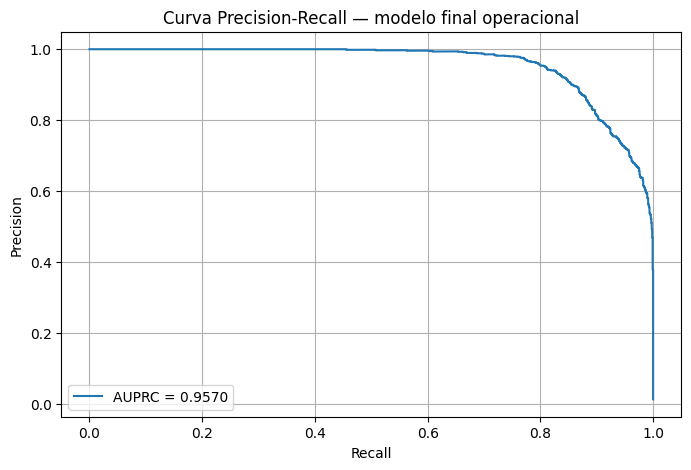

In [55]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_score_test_melhor)
auprc_melhor = average_precision_score(y_test, y_score_test_melhor)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f"AUPRC = {auprc_melhor:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — modelo final operacional")
plt.legend()
plt.grid(True)
plt.show()

## 16. Robustez por Imbalance Ratio

Este teste responde diretamente à pergunta da proposta:

> até que nível de desbalanceamento o modelo mantém recall e F1 aceitáveis?

A avaliação cria subconjuntos do teste com proporções aproximadas:

- IR 1:100
- IR 1:500
- IR 1:1000
- IR 1:2000

In [56]:
def criar_subconjunto_por_ir(
    X: pd.DataFrame,
    y: pd.Series,
    imbalance_ratio: int,
    max_fraudes: int = 300,
    random_state: int = RANDOM_STATE,
):
    dados = X.copy()
    dados[COLUNA_ALVO] = y.values

    fraudes = dados[dados[COLUNA_ALVO] == 1]
    legitimas = dados[dados[COLUNA_ALVO] == 0]

    n_fraudes_possivel = min(
        len(fraudes),
        len(legitimas) // imbalance_ratio,
        max_fraudes,
    )

    if n_fraudes_possivel <= 0:
        raise ValueError(f"Não há dados suficientes para criar IR 1:{imbalance_ratio}.")

    n_legitimas = n_fraudes_possivel * imbalance_ratio

    fraudes_amostra = fraudes.sample(n=n_fraudes_possivel, random_state=random_state)
    legitimas_amostra = legitimas.sample(n=n_legitimas, random_state=random_state)

    amostra = pd.concat([fraudes_amostra, legitimas_amostra], axis=0)
    amostra = amostra.sample(frac=1, random_state=random_state).reset_index(drop=True)

    X_ir = amostra.drop(columns=[COLUNA_ALVO])
    y_ir = amostra[COLUNA_ALVO].astype(int)

    return X_ir, y_ir


irs_avaliar = [100, 500, 1000, 2000]
resultados_ir = []

for ir in irs_avaliar:
    try:
        X_ir, y_ir = criar_subconjunto_por_ir(
            X_test_melhor,
            y_test,
            imbalance_ratio=ir,
            max_fraudes=300,
            random_state=RANDOM_STATE + ir,
        )

        y_score_ir = obter_probabilidade_fraude(melhor_modelo, X_ir)
        y_pred_ir = (y_score_ir >= melhor_threshold).astype(int)

        tempo_medio_ir, tempo_p95_ir = medir_tempo_inferencia(
            lambda X: obter_probabilidade_fraude(melhor_modelo, X),
            X_ir,
        )

        metricas_ir = calcular_metricas(
            y_true=y_ir,
            y_pred=y_pred_ir,
            y_score=y_score_ir,
            nome_modelo=melhor_modelo_base,
            cenario_features=melhor_cenario,
            threshold=melhor_threshold,
            tempo_medio_ms=tempo_medio_ir,
            tempo_p95_ms=tempo_p95_ir,
            conjunto=f"teste_IR_1:{ir}",
        )

        metricas_ir["imbalance_ratio_alvo"] = ir
        metricas_ir["total_amostra"] = len(y_ir)
        metricas_ir["fraudes_amostra"] = int(y_ir.sum())
        metricas_ir["legitimas_amostra"] = int((y_ir == 0).sum())

        resultados_ir.append(metricas_ir)

    except Exception as erro:
        print(f"Não foi possível avaliar IR 1:{ir}: {erro}")

resultados_ir_df = pd.DataFrame(resultados_ir)

if len(resultados_ir_df) > 0:
    colunas_ir = [
        "conjunto",
        "imbalance_ratio_alvo",
        "total_amostra",
        "fraudes_amostra",
        "legitimas_amostra",
        "precision_fraude",
        "recall_fraude",
        "f1_fraude",
        "auprc",
        "fp",
        "fn",
        "custo_total",
        "tempo_medio_ms_por_transacao",
        "tempo_p95_ms_por_transacao",
    ]

    display(resultados_ir_df[colunas_ir])
else:
    print("Nenhum cenário de IR foi avaliado.")

,conjunto,imbalance_ratio_alvo,total_amostra,fraudes_amostra,legitimas_amostra,precision_fraude,recall_fraude,f1_fraude,auprc,fp,fn,custo_total,tempo_medio_ms_por_transacao,tempo_p95_ms_por_transacao
0,teste_IR_1:100,100,30300,300,30000,0.905263,0.860000,0.882051,0.953338,27,42,21270,0.004516,0.004801
1,teste_IR_1:500,500,88176,176,88000,0.622490,0.880682,0.729412,0.880597,94,21,11440,0.004492,0.004967
2,teste_IR_1:1000,1000,88088,88,88000,0.437126,0.829545,0.572549,0.776208,94,15,8440,0.004370,0.004461
3,teste_IR_1:2000,2000,88044,44,88000,0.279070,0.818182,0.416185,0.701192,93,8,4930,0.004381,0.004521


## 17. Resumo textual para o relatório

Esta célula gera um texto curto com os principais resultados do modelo final.

In [57]:
if len(resultado_teste_final) > 0:
    linha = resultado_teste_final.iloc[0]

    print("Resumo para relatório:")
    print(f"- Modelo final operacional: {melhor_modelo_base}.")
    print(f"- Cenário de features: {melhor_cenario}.")
    print(f"- Threshold selecionado na validação: {melhor_threshold:.4f}.")
    print(f"- Precision da fraude no teste: {linha['precision_fraude']:.4f}.")
    print(f"- Recall da fraude no teste: {linha['recall_fraude']:.4f}.")
    print(f"- F1-score da fraude no teste: {linha['f1_fraude']:.4f}.")
    print(f"- AUPRC no teste: {linha['auprc']:.4f}.")
    print(f"- FP: {int(linha['fp'])}.")
    print(f"- FN: {int(linha['fn'])}.")
    print(f"- Custo total simulado: {linha['custo_total']:,.2f}.")
    print(f"- Tempo médio por transação: {linha['tempo_medio_ms_por_transacao']:.6f} ms.")
    print(f"- p95 por transação: {linha['tempo_p95_ms_por_transacao']:.6f} ms.")

if len(resultados_ir_df) > 0:
    ir_aprovados = resultados_ir_df[resultados_ir_df["recall_fraude"] >= META_RECALL]["imbalance_ratio_alvo"].tolist()

    if ir_aprovados:
        print(f"- O modelo manteve recall >= {META_RECALL:.2f} até IR 1:{max(ir_aprovados)} nos cenários testados.")
    else:
        print(f"- O modelo não manteve recall >= {META_RECALL:.2f} nos cenários de IR testados.")

Resumo para relatório:
- Modelo final operacional: XGBoost - scale_pos_weight.
- Cenário de features: sem_pos_transacao.
- Threshold selecionado na validação: 0.9900.
- Precision da fraude no teste: 0.9183.
- Recall da fraude no teste: 0.8442.
- F1-score da fraude no teste: 0.8797.
- AUPRC no teste: 0.9570.
- FP: 94.
- FN: 195.
- Custo total simulado: 98,440.00.
- Tempo médio por transação: 0.004371 ms.
- p95 por transação: 0.004517 ms.
- O modelo manteve recall >= 0.80 até IR 1:2000 nos cenários testados.


## 18. Salvamento dos artefatos

Os arquivos salvos aqui alimentam o relatório e o futuro dashboard Streamlit.

In [58]:
caminho_resultados_validacao = OUTPUT_DIR / "resultados_validacao.csv"
caminho_resultados_teste = OUTPUT_DIR / "resultados_teste.csv"
caminho_tabela_principal = OUTPUT_DIR / "tabela_principal_modelos.csv"
caminho_resultado_final = OUTPUT_DIR / "resultado_modelo_final.csv"
caminho_resultados_ir = OUTPUT_DIR / "resultados_robustez_imbalance_ratio.csv"

resultados_validacao_df.to_csv(caminho_resultados_validacao, index=False)
resultados_teste_df.to_csv(caminho_resultados_teste, index=False)
tabela_principal_modelos.to_csv(caminho_tabela_principal, index=False)
resultado_teste_final.to_csv(caminho_resultado_final, index=False)

if len(resultados_ir_df) > 0:
    resultados_ir_df.to_csv(caminho_resultados_ir, index=False)

predicoes_teste = pd.DataFrame({
    "y_true": y_test.values,
    "probabilidade_fraude": y_score_test_melhor,
    "pred_threshold_otimizado": y_pred_test_melhor,
    "threshold_usado": melhor_threshold,
})

caminho_predicoes_csv = OUTPUT_DIR / "predicoes_teste_melhor_modelo.csv"
predicoes_teste.to_csv(caminho_predicoes_csv, index=False)

caminho_modelo = None

if JOBLIB_DISPONIVEL:
    caminho_modelo = OUTPUT_DIR / "melhor_modelo.joblib"
    joblib.dump(melhor_modelo, caminho_modelo)

metadata_modelagem = {
    "data_execucao": datetime.now().isoformat(timespec="seconds"),
    "modo_rapido": MODO_RAPIDO,
    "cenario_final_operacional": CENARIO_FINAL_OPERACIONAL,
    "max_legitimas_treino": MAX_LEGITIMAS_TREINO,
    "max_legitimas_smote": MAX_LEGITIMAS_SMOTE,
    "custos": {
        "custo_fp": CUSTO_FP,
        "custo_fn": CUSTO_FN,
    },
    "metas": {
        "recall_minimo": META_RECALL,
        "precision_minima": META_PRECISION,
        "tempo_medio_ms_maximo": META_TEMPO_MEDIO_MS,
    },
    "melhor_modelo_base": melhor_modelo_base,
    "melhor_cenario_features": melhor_cenario,
    "melhor_threshold": melhor_threshold,
    "criterio_selecao": criterio_selecao,
    "features_usadas": features_melhor_modelo,
    "arquivos_gerados": {
        "resultados_validacao": str(caminho_resultados_validacao),
        "resultados_teste": str(caminho_resultados_teste),
        "tabela_principal_modelos": str(caminho_tabela_principal),
        "resultado_modelo_final": str(caminho_resultado_final),
        "resultados_ir": str(caminho_resultados_ir),
        "predicoes_teste": str(caminho_predicoes_csv),
        "modelo": str(caminho_modelo) if caminho_modelo else None,
    },
}

caminho_metadata_modelagem = OUTPUT_DIR / "metadata_modelagem.json"

with open(caminho_metadata_modelagem, "w", encoding="utf-8") as arquivo:
    json.dump(metadata_modelagem, arquivo, ensure_ascii=False, indent=4)

print("Arquivos salvos:")
print(f"- {caminho_resultados_validacao}")
print(f"- {caminho_resultados_teste}")
print(f"- {caminho_tabela_principal}")
print(f"- {caminho_resultado_final}")
print(f"- {caminho_resultados_ir}")
print(f"- {caminho_predicoes_csv}")
print(f"- {caminho_metadata_modelagem}")

if caminho_modelo:
    print(f"- {caminho_modelo}")

Arquivos salvos:
- data/modelagem/resultados_validacao.csv
- data/modelagem/resultados_teste.csv
- data/modelagem/tabela_principal_modelos.csv
- data/modelagem/resultado_modelo_final.csv
- data/modelagem/resultados_robustez_imbalance_ratio.csv
- data/modelagem/predicoes_teste_melhor_modelo.csv
- data/modelagem/metadata_modelagem.json
- data/modelagem/melhor_modelo.joblib
